# 1. Preprocessing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from keras.backend import clear_session

# ── Load Data ────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape)
print(x_test.shape)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


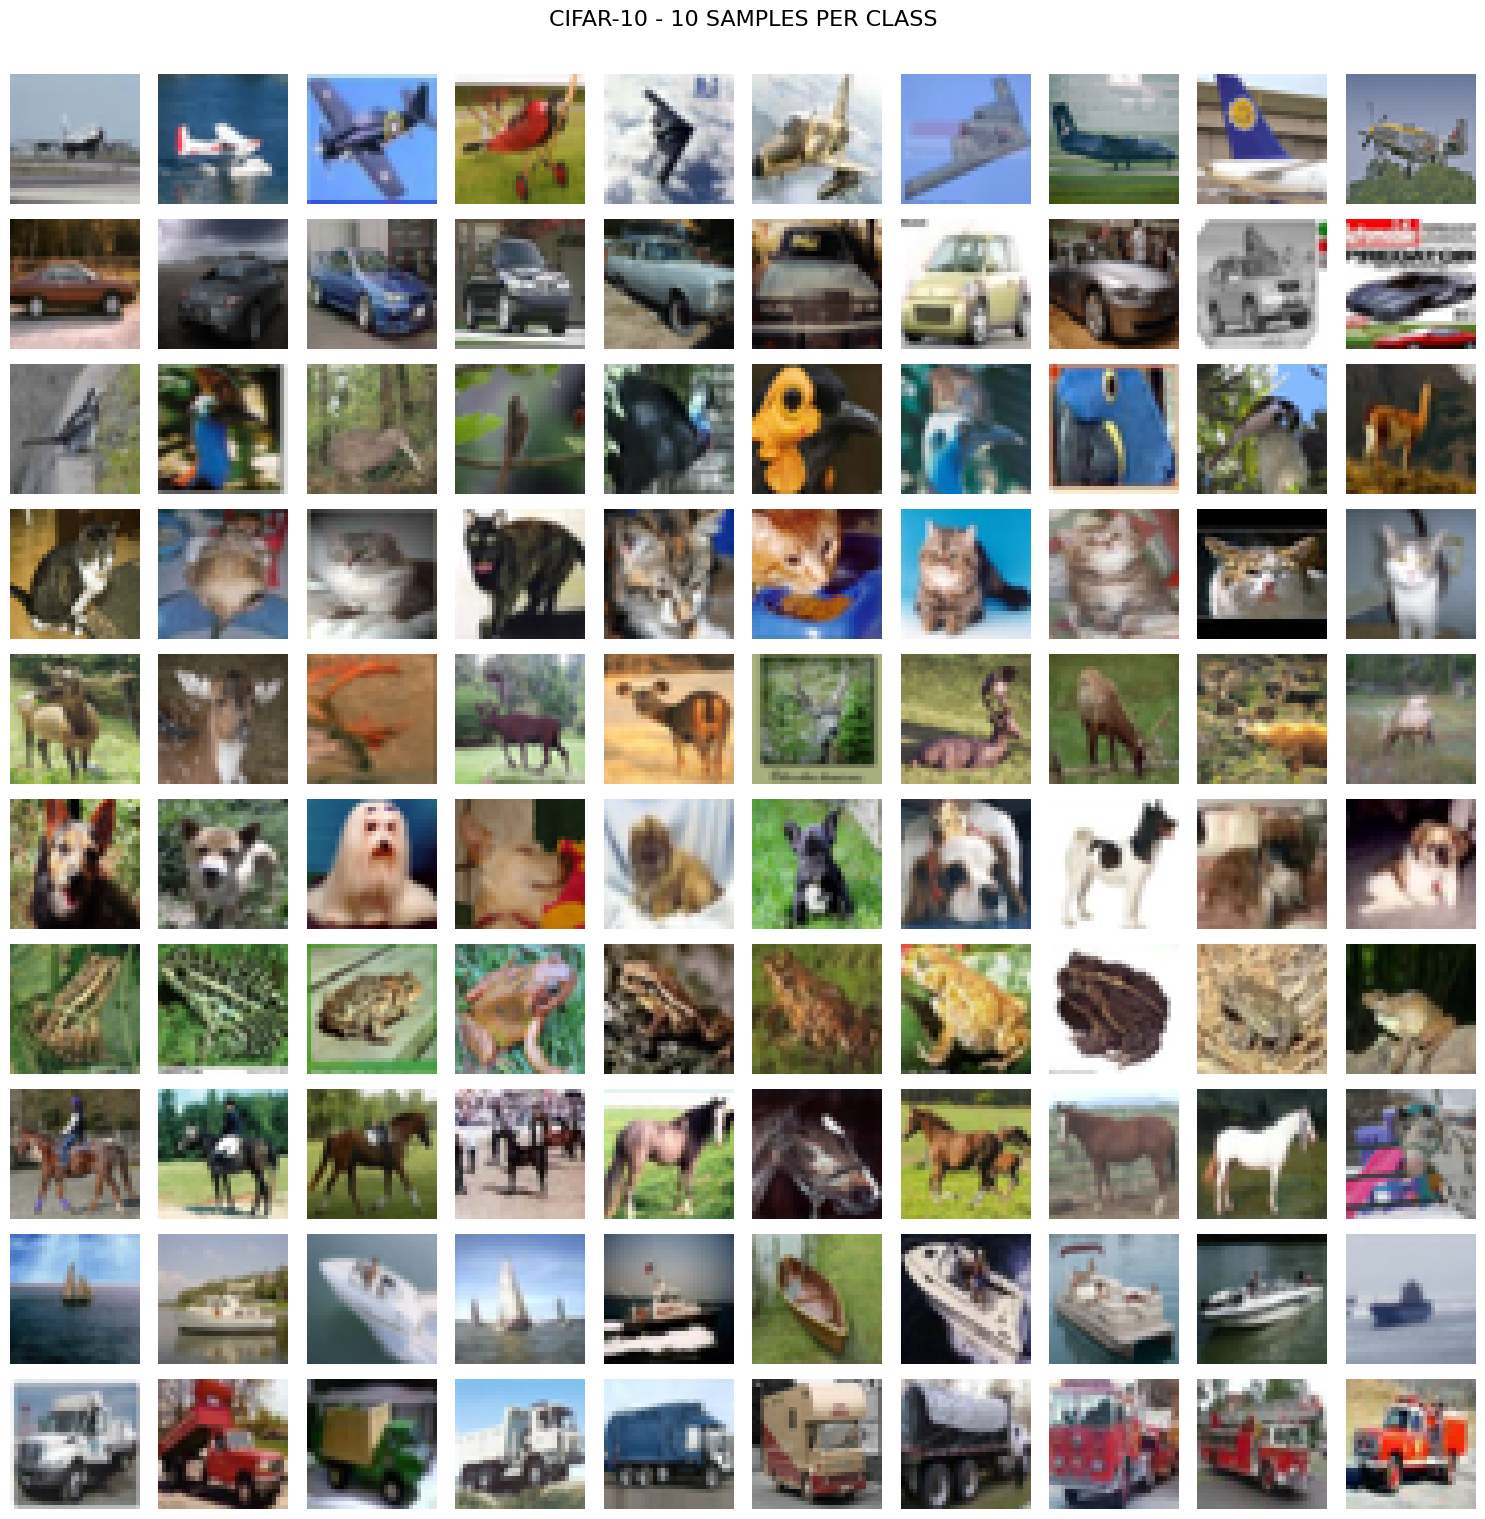

In [2]:

# ── Visualize ────────────────────────────────────────
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle('CIFAR-10 - 10 SAMPLES PER CLASS', fontsize=16, y=1.01)

for class_idx in range(10):
    indices = np.where(y_train.flatten() == class_idx)[0]
    samples = np.random.choice(indices, 10, replace=False)
    for col, sample_idx in enumerate(samples):
        ax = axes[class_idx, col]
        ax.imshow(x_train[sample_idx])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_names[class_idx], fontsize=9,
                          rotation=0, labelpad=50, va='center')

plt.tight_layout()
plt.show()

In [3]:
# ── One-Hot Encode & Normalize ───────────────────────
y_train_Cat = to_categorical(y_train, num_classes=10)
y_test_Cat  = to_categorical(y_test,  num_classes=10)
print('Shape before:', y_train.shape, '→ after:', y_train_Cat.shape)

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0
print('pixel min=', x_train_norm.min(), 'pixel max=', x_train_norm.max())

# ── Train/Validation Split ───────────────────────────
x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train_norm, y_train_Cat,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print(f"Training samples:   {x_train_split.shape[0]}")
print(f"Validation samples: {x_val.shape[0]}")

Shape before: (50000, 1) → after: (50000, 10)
pixel min= 0.0 pixel max= 1.0
Training samples:   45000
Validation samples: 5000


# 2. Model Architecture (Data Augmentation)

In [4]:
# ── Build Model ──────────────────────────────────────
clear_session()

model10 = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(10, activation='softmax')
])

model10.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,425,034 (5.44 MB)

 Trainable params: 1,423,626 (5.43 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [5]:
# ── Data Augmentation ────────────────────────────────
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    fill_mode='nearest'
)
train_datagen.fit(x_train_split)

In [6]:
# ── Compile ──────────────────────────────────────────
model10.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


# 3. Training

In [7]:
# ── Train ────────────────────────────────────────────
history3 = model10.fit(
    train_datagen.flow(x_train_split, y_train_split, batch_size=128),
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.4132 - loss: 2.1636 - val_accuracy: 0.2152 - val_loss: 3.5534 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.5442 - loss: 1.6113 - val_accuracy: 0.4904 - val_loss: 1.7555 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.6057 - loss: 1.3670 - val_accuracy: 0.6222 - val_loss: 1.4002 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.6436 - loss: 1.2388 - val_accuracy: 0.5726 - val_loss: 1.5109 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6641 - loss: 1.1840 - val_accuracy: 0.6244 - val_loss: 1.4071 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.6753 - loss: 1.1681 - val_accuracy: 0.6542 - val_loss: 1.3329 - learning_rate: 0.0010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.6894 - l

# 4. Performance

Final Training Loss:     0.5570
Final Training Accuracy: 84.45%
Validation Loss:         0.5263
Validation Accuracy:     85.86%
Test Loss:               0.5584
Test Accuracy:           85.51%


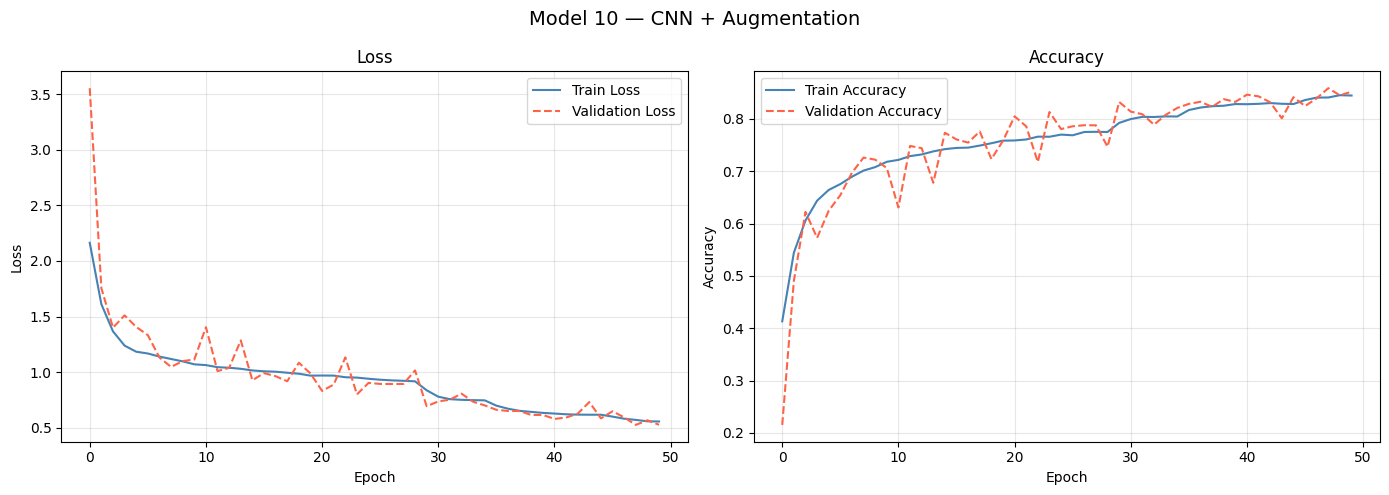

In [13]:
# ── Evaluate ─────────────────────────────────────────
val_loss3,  val_acc3  = model10.evaluate(x_val,       y_val,      verbose=0)
test_loss3, test_acc3 = model10.evaluate(x_test_norm, y_test_Cat, verbose=0)

print(f"Final Training Loss:     {history3.history['loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history3.history['accuracy'][-1]*100:.2f}%")
print(f"Validation Loss:         {val_loss3:.4f}")
print(f"Validation Accuracy:     {val_acc3*100:.2f}%")
print(f"Test Loss:               {test_loss3:.4f}")
print(f"Test Accuracy:           {test_acc3*100:.2f}%")

# ── Training Curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 10 — CNN + Augmentation', fontsize=14)

axes[0].plot(history3.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history3.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history3.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(history3.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

    airplane       0.89      0.90      0.89       500
  automobile       0.93      0.94      0.93       500
        bird       0.84      0.78      0.81       500
         cat       0.76      0.70      0.72       500
        deer       0.87      0.87      0.87       500
         dog       0.87      0.68      0.76       500
        frog       0.72      0.95      0.82       500
       horse       0.89      0.90      0.90       500
        ship       0.95      0.94      0.94       500
       truck       0.92      0.93      0.92       500

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



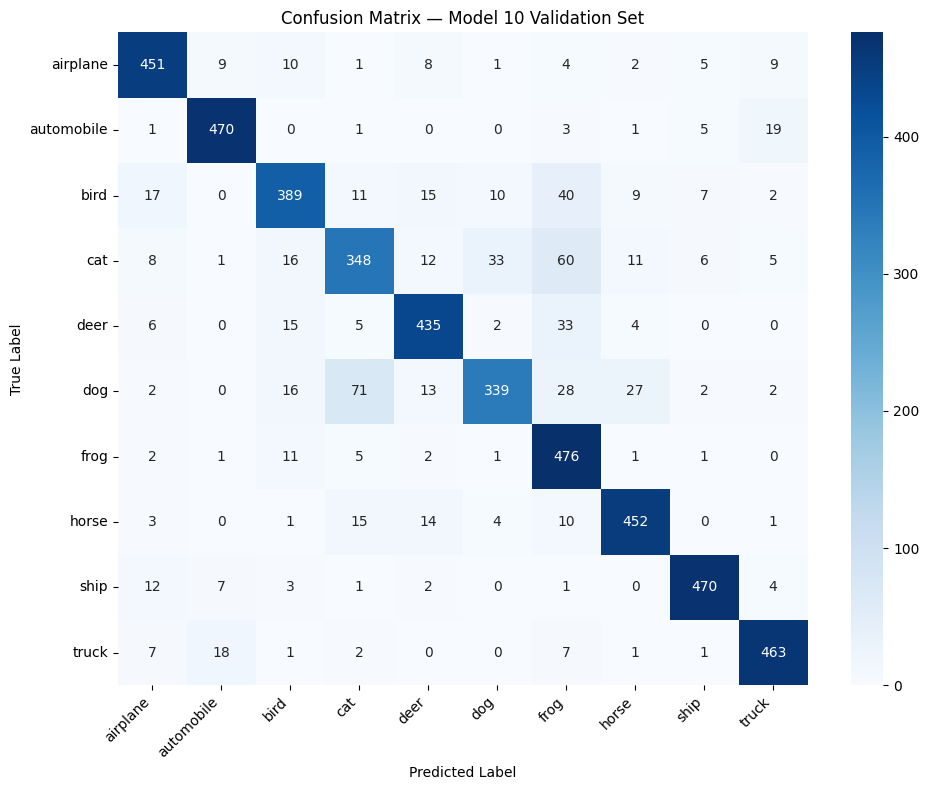

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


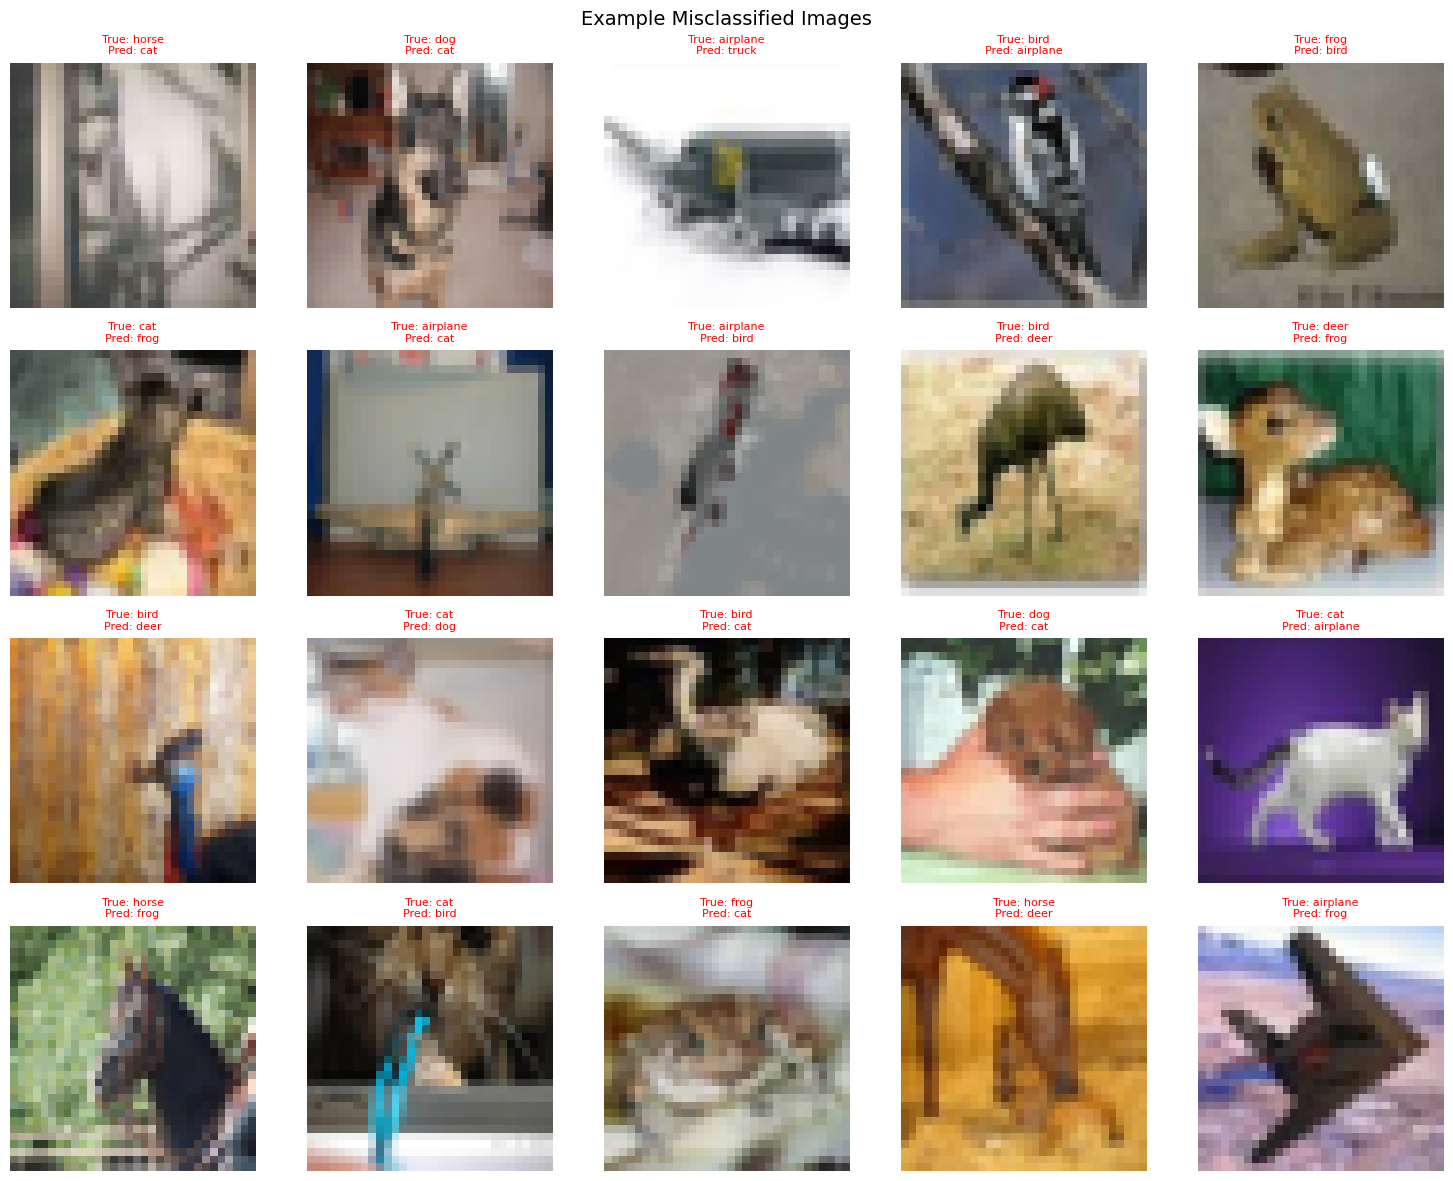

Total misclassified: 707 / 5000


In [9]:
# ── Classification Report & Confusion Matrix ──────────
y_val_pred_probs = model10.predict(x_val)
y_val_pred3      = np.argmax(y_val_pred_probs, axis=1)
y_val_true       = np.argmax(y_val, axis=1)

print(classification_report(y_val_true, y_val_pred3, target_names=class_names))

cm3 = confusion_matrix(y_val_true, y_val_pred3)
plt.figure(figsize=(10, 8))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Model 10 Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find misclassified images
y_val_pred_probs = model10.predict(x_val)
y_val_pred3      = np.argmax(y_val_pred_probs, axis=1)
y_val_true       = np.argmax(y_val, axis=1)

errors = np.where(y_val_pred3 != y_val_true)[0]

# Plot first 10 misclassified images
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Example Misclassified Images', fontsize=14)

for i, idx in enumerate(errors[:20]):
    ax = axes[i//5, i%5]
    ax.imshow(x_val[idx])
    ax.axis('off')
    ax.set_title(f'True: {class_names[y_val_true[idx]]}\nPred: {class_names[y_val_pred3[idx]]}',
                 fontsize=8, color='red')

plt.tight_layout()
plt.show()
print(f"Total misclassified: {len(errors)} / {len(y_val_true)}")

In [10]:
import gradio as gr
import numpy as np
import tensorflow as tf
from PIL import Image

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def predict_image(img):
    # Resize to 32x32 (CIFAR-10 input size)
    img = Image.fromarray(img).resize((32, 32))

    # Convert to numpy array and normalize
    img_array = np.array(img).astype('float32') / 255.0

    # Add batch dimension → (1, 32, 32, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Get predictions
    predictions = model10.predict(img_array, verbose=0)
    probabilities = predictions[0]

    # Return as dictionary of class → confidence
    return {class_names[i]: float(probabilities[i]) for i in range(10)}

# Build Gradio interface
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type='numpy', label='Upload an Image'),
    outputs=gr.Label(num_top_classes=5, label='Top 5 Predictions'),
    title='CIFAR-10 Image Classifier',
    description='Upload any image and the model will predict which of the 10 CIFAR-10 classes it belongs to: airplane, automobile, bird, cat, deer, dog, frog, horse, ship or truck.',
    examples=[],
    theme='soft'
)

interface.launch(share=True)   # share=True generates a public link

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://93f3e6fc93c759c0e2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Accuracy improvement rate: 0.5788% per epoch
Projected final accuracy:  90.35%


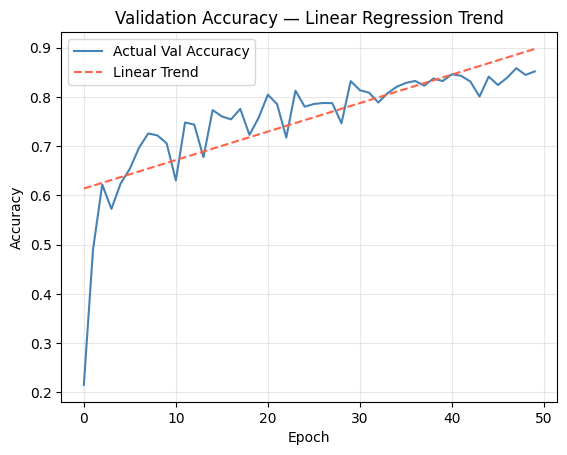

In [11]:
from sklearn.linear_model import LinearRegression
import numpy as np

# ← change history10 to match your actual variable name
epochs   = np.arange(len(history3.history['val_accuracy'])).reshape(-1, 1)
val_accs = np.array(history3.history['val_accuracy'])

reg = LinearRegression()
reg.fit(epochs, val_accs)

print(f"Accuracy improvement rate: {reg.coef_[0]*100:.4f}% per epoch")
print(f"Projected final accuracy:  {reg.predict([[50]])[0]*100:.2f}%")

plt.plot(epochs, val_accs,            label='Actual Val Accuracy', color='steelblue')
plt.plot(epochs, reg.predict(epochs), label='Linear Trend',        color='tomato', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy — Linear Regression Trend')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()